# Week 6 · Single-cell RNA-seq mini-pipeline

This notebook reconstructs the complete processing flow for the toy single-cell dataset shipped with the assignment. It fetches the raw FASTQ files and reference material, quantifies expression with **simpleaf/alevin-fry**, clusters cells with **Scanpy/Leiden**, and annotates them with **CellTypist**. The goal is to keep the workflow reproducible and CI-friendly, so every step—from downloading barcodes to generating plots—runs automatically when the notebook executes.

## Roadmap
1. Set up paths, helper utilities, and seeds
2. Prepare the FASTQ, reference, and whitelist inputs (from the committed archive)
3. Build a splici index and quantify with `simpleaf` (salmon + alevin-fry)
4. Load counts into an `AnnData` via `pyroe`, retaining raw counts
5. Map Ensembl IDs to gene symbols using the bundled GTF
6. Normalize, reduce, and cluster with Scanpy (PCA → neighbors → Leiden/UMAP)
7. Run CellTypist for automated annotations and visualize predictions
8. Summarize outputs and document runtime estimates

## Setup: Install dependencies

First, we need to install the necessary tools. This cell installs simpleaf and other required packages if they're not already available.


In [5]:
# Install dependencies if not already available
import subprocess
import sys
import shutil

# Check if simpleaf is available
if shutil.which("simpleaf") is None:
    print("simpleaf not found, attempting to install via conda/mamba...")
    try:
        # Try mamba first (faster)
        subprocess.run(["mamba", "install", "-y", "-c", "bioconda", "-c", "conda-forge", "simpleaf"], check=True)
        print("simpleaf installed successfully via mamba")
    except (subprocess.CalledProcessError, FileNotFoundError):
        try:
            # Fall back to conda
            subprocess.run(["conda", "install", "-y", "-c", "bioconda", "-c", "conda-forge", "simpleaf"], check=True)
            print("simpleaf installed successfully via conda")
        except (subprocess.CalledProcessError, FileNotFoundError):
            print("WARNING: Could not install simpleaf automatically.")
            print("Please install it manually:")
            print("  conda install -c bioconda -c conda-forge simpleaf")
            print("  OR")
            print("  mamba install -c bioconda -c conda-forge simpleaf")
else:
    print("simpleaf is already installed")

# Install Python packages if needed
required_packages = ["scanpy", "celltypist", "leidenalg", "python-igraph", "umap-learn", "anndata", "pyroe", "mygene"]
missing_packages = []

for package in required_packages:
    try:
        __import__(package.replace("-", "_"))
    except ImportError:
        missing_packages.append(package)

if missing_packages:
    print(f"Installing missing Python packages: {', '.join(missing_packages)}")
    subprocess.run([sys.executable, "-m", "pip", "install"] + missing_packages, check=True)
    print("Python packages installed successfully")
else:
    print("All required Python packages are already installed")


simpleaf is already installed
Installing missing Python packages: python-igraph, umap-learn
Python packages installed successfully


In [6]:
from __future__ import annotations

import json
import os
import re
import shutil
import subprocess
import tarfile
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

# Now import the packages that were installed
import numpy as np
import pandas as pd
import scanpy as sc
import celltypist
from celltypist import models
import pyroe

analysis_start = time.time()
PROJECT_ROOT = Path.cwd()
WEEK6_DIR = PROJECT_ROOT
WORK_DIR = WEEK6_DIR / "af_work"
WORK_DIR.mkdir(parents=True, exist_ok=True)
THREADS = int(os.environ.get("THREADS", "4"))
ALEVIN_FRY_HOME = WORK_DIR / "alevin_fry_home"
ALEVIN_FRY_HOME.mkdir(parents=True, exist_ok=True)
os.environ["ALEVIN_FRY_HOME"] = str(ALEVIN_FRY_HOME)
sc.settings.verbosity = 2
sc.set_figure_params(figsize=(4, 4), dpi=120)
np.random.seed(0)

print(f"Project root: {PROJECT_ROOT}")
print(f"Work directory: {WORK_DIR}")
print(f"Threads: {THREADS}")

Project root: /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6
Work directory: /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work
Threads: 4


## 1. Prepare inputs (FASTQ, reference, whitelist)
The assignment ships `toy_read_ref_set.tar.gz` and `3M-february-2018.txt.gz`. We extract everything under `week6/af_work/` on the fly so that CI jobs stay fully self-contained.

In [7]:
archive_path = WEEK6_DIR / "toy_read_ref_set.tar.gz"
fastq_dir = WORK_DIR / "toy_read_fastq"
ref_dir = WORK_DIR / "toy_human_ref"

# Check if the actual files exist, not just the directories
# This ensures proper extraction even if directories exist but are empty
genome_fa = ref_dir / "fasta" / "genome.fa"
genes_gtf = ref_dir / "genes" / "genes.gtf"
r1_fastq = list(fastq_dir.glob("*_R1_*.fastq*")) if fastq_dir.exists() else []
r2_fastq = list(fastq_dir.glob("*_R2_*.fastq*")) if fastq_dir.exists() else []

if not (genome_fa.exists() and genes_gtf.exists() and r1_fastq and r2_fastq):
    if not archive_path.exists():
        raise FileNotFoundError(f"Missing archive: {archive_path}")
    print(f"Extracting {archive_path} → {WORK_DIR}")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(WORK_DIR)
    
    # The tar file contains a top-level directory "toy_ref_read"
    # Move the contents to the expected locations
    extracted_dir = WORK_DIR / "toy_ref_read"
    if extracted_dir.exists():
        # Move subdirectories to expected locations
        if (extracted_dir / "toy_human_ref").exists():
            if ref_dir.exists():
                shutil.rmtree(ref_dir)
            shutil.move(str(extracted_dir / "toy_human_ref"), str(ref_dir))
        if (extracted_dir / "toy_read_fastq").exists():
            if fastq_dir.exists():
                shutil.rmtree(fastq_dir)
            shutil.move(str(extracted_dir / "toy_read_fastq"), str(fastq_dir))
        # Clean up the extracted directory
        shutil.rmtree(extracted_dir)
    
    print("Extraction and reorganization complete.")
else:
    print("FASTQ and reference files already present; skipping extraction.")

whitelist_gz = WEEK6_DIR / "3M-february-2018.txt.gz"
whitelist_txt = WORK_DIR / "3M-february-2018.txt"
if whitelist_txt.exists():
    print("Whitelist already available; skipping decompression.")
elif whitelist_gz.exists():
    import gzip
    print("Decompressing whitelist…")
    with gzip.open(whitelist_gz, "rb") as fin, open(whitelist_txt, "wb") as fout:
        shutil.copyfileobj(fin, fout)
else:
    import urllib.request
    url = "https://raw.githubusercontent.com/10XGenomics/cellranger/master/lib/python/cellranger/barcodes/3M-february-2018.txt.gz"
    print(f"Downloading whitelist from {url}")
    tmp_gz = WORK_DIR / "3M-february-2018.txt.gz"
    urllib.request.urlretrieve(url, tmp_gz)
    with gzip.open(tmp_gz, "rb") as fin, open(whitelist_txt, "wb") as fout:
        shutil.copyfileobj(fin, fout)
    tmp_gz.unlink()

print(f"FASTQ dir: {fastq_dir}")
print(f"Reference dir: {ref_dir}")
print(f"Whitelist: {whitelist_txt}")

FASTQ and reference files already present; skipping extraction.
Whitelist already available; skipping decompression.
FASTQ dir: /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/toy_read_fastq
Reference dir: /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/toy_human_ref
Whitelist: /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/3M-february-2018.txt


## 2. Run simpleaf/alevin-fry
We follow the *single-cell best practices* mini tutorial: configure `ALEVIN_FRY_HOME`, call `simpleaf set-paths`, build a splici index, and quantify the toy reads in USA (unspliced/spliced/ambiguous) mode.

In [19]:
from pathlib import Path
from typing import Iterable
import subprocess
import shutil

def run_command(cmd: Iterable[str], cwd: Path | None = None) -> None:
    cmd = list(map(str, cmd))
    print("$", " ".join(cmd))
    try:
        result = subprocess.run(cmd, cwd=cwd, check=False, capture_output=True, text=True)
        if result.returncode != 0:
            print(f"Command failed with exit code {result.returncode}")
            print("STDERR:", result.stderr)
            print("STDOUT:", result.stdout)
            raise subprocess.CalledProcessError(result.returncode, cmd)
    except FileNotFoundError as e:
        if "simpleaf" in str(cmd[0]):
            print(f"ERROR: simpleaf not found. Please install it first:")
            print("  conda install -c bioconda -c conda-forge simpleaf")
            print("  OR")
            print("  mamba install -c bioconda -c conda-forge simpleaf")
            raise RuntimeError("simpleaf is required but not installed") from e
        else:
            raise

# Check if simpleaf is available before proceeding
if shutil.which("simpleaf") is None:
    print("WARNING: simpleaf is not installed. Skipping quantification steps.")
    print("The notebook will continue with pre-computed results if available.")
    simpleaf_available = False
else:
    simpleaf_available = True
    run_command(["simpleaf", "set-paths"])

if simpleaf_available:
    index_dir = WORK_DIR / "simpleaf_index"
    if not index_dir.exists():
        run_command(
            [
                "simpleaf",
                "index",
                "-o",
                index_dir,
                "-f",
                ref_dir / "fasta" / "genome.fa",
                "-g",
                ref_dir / "genes" / "genes.gtf",
                "-r",
                "90",
                "-t",
                str(THREADS),
            ],
            cwd=WORK_DIR,
        )
    else:
        print("simpleaf index already present; skipping.")

    reads1 = sorted(fastq_dir.glob("*_R1_*.fastq*"))
    reads2 = sorted(fastq_dir.glob("*_R2_*.fastq*"))
    if not reads1 or not reads2:
        raise RuntimeError("Could not find R1/R2 FASTQs in toy_read_fastq.")
    reads1_arg = ",".join(str(p) for p in reads1)
    reads2_arg = ",".join(str(p) for p in reads2)
    quant_dir = WORK_DIR / "simpleaf_quant"
    if not quant_dir.exists():
        # Check if whitelist exists
        full_whitelist_path = WORK_DIR / "3M-february-2018.txt"
        filtered_whitelist_path = WORK_DIR / "filtered_whitelist.txt"
        
        # Create a filtered whitelist for the toy dataset
        # Extract barcodes from R1 reads and filter the whitelist
        if full_whitelist_path.exists() and not filtered_whitelist_path.exists():
            print("Creating filtered whitelist for toy dataset...")
            
            # Read all valid barcodes from the full whitelist
            with open(full_whitelist_path, 'r') as f:
                valid_barcodes = set(line.strip() for line in f)
            
            # Extract barcodes from R1 reads (first 16bp of each read)
            observed_barcodes = set()
            for r1_file in reads1:
                with open(r1_file, 'r') as f:
                    line_num = 0
                    for line in f:
                        line_num += 1
                        if line_num % 4 == 2:  # Sequence line in FASTQ
                            barcode = line[:16]  # First 16bp is the barcode
                            if barcode in valid_barcodes:
                                observed_barcodes.add(barcode)
            
            # Write filtered whitelist
            with open(filtered_whitelist_path, 'w') as f:
                for bc in sorted(observed_barcodes):
                    f.write(bc + '\n')
            
            print(f"Created filtered whitelist with {len(observed_barcodes)} barcodes (from {len(valid_barcodes):,} total)")
        
        # Use the filtered whitelist if it exists, otherwise try the full one
        whitelist_to_use = filtered_whitelist_path if filtered_whitelist_path.exists() else full_whitelist_path
        
        # Try to use the whitelist with --explicit-pl
        if whitelist_to_use.exists():
            print(f"Attempting to use whitelist with --explicit-pl: {whitelist_to_use}")
            quant_cmd = [
                "simpleaf",
                "quant",
                "-c",
                "10xv3",
                "-t",
                str(THREADS),
                "-1",
                reads1_arg,
                "-2",
                reads2_arg,
                "-i",
                index_dir / "index",
                "-x",  # Short form of --explicit-pl
                str(whitelist_to_use),
                "-r",
                "cr-like",
                "-m",
                index_dir / "index" / "t2g_3col.tsv",
                "-o",
                quant_dir,
            ]
            
            try:
                run_command(quant_cmd, cwd=WORK_DIR)
                print(f"✅ Quantification completed successfully WITH explicit whitelist: {whitelist_to_use}")
            except subprocess.CalledProcessError as e:
                print("Could not use --explicit-pl with filtered whitelist. Falling back to chemistry defaults...")
                
                # Remove partially created directory
                if quant_dir.exists():
                    shutil.rmtree(quant_dir)
                
                # Fall back to minimal command that we know works
                quant_cmd = [
                    "simpleaf",
                    "quant",
                    "-c",
                    "10xv3",
                    "-t",
                    str(THREADS),
                    "-1",
                    reads1_arg,
                    "-2",
                    reads2_arg,
                    "-i",
                    index_dir / "index",
                    "-u",
                    "-r",
                    "cr-like",
                    "-m",
                    index_dir / "index" / "t2g_3col.tsv",
                    "-o",
                    quant_dir,
                ]
                
                run_command(quant_cmd, cwd=WORK_DIR)
                print("⚠️ Quantification completed with chemistry defaults (whitelist could not be explicitly used)")
        else:
            print("Whitelist not found. Running with chemistry defaults...")
            
            quant_cmd = [
                "simpleaf",
                "quant",
                "-c",
                "10xv3",
                "-t",
                str(THREADS),
                "-1",
                reads1_arg,
                "-2",
                reads2_arg,
                "-i",
                index_dir / "index",
                "-u",
                "-r",
                "cr-like",
                "-m",
                index_dir / "index" / "t2g_3col.tsv",
                "-o",
                quant_dir,
            ]
            
            run_command(quant_cmd, cwd=WORK_DIR)
            print("Quantification completed successfully with chemistry defaults")
    else:
        print("simpleaf quant already finished; skipping.")
else:
    quant_dir = WORK_DIR / "simpleaf_quant"
    if not quant_dir.exists():
        print("=" * 70)
        print("ERROR: simpleaf is not available and no pre-computed quantification found.")
        print("=" * 70)
        print("\nTo fix this issue, you have several options:")
        print("\n1. Install simpleaf using conda/mamba:")
        print("   conda install -c bioconda -c conda-forge simpleaf")
        print("   OR")
        print("   mamba install -c bioconda -c conda-forge simpleaf")
        print("\n2. If installation fails, you can provide pre-computed results by:")
        print(f"   - Creating the directory: {quant_dir}")
        print("   - Adding pre-computed alevin-fry quantification results there")
        print("\n3. For CI environments, ensure simpleaf is installed in the workflow:")
        print("   - Add to .github/workflows/actions.yml:")
        print("     mamba install -c bioconda -c conda-forge simpleaf")
        print("=" * 70)
        raise RuntimeError("Cannot proceed without quantification results. See above for solutions.")


$ simpleaf set-paths
simpleaf index already present; skipping.
Creating filtered whitelist for toy dataset...
Created filtered whitelist with 1787 barcodes (from 6,794,880 total)
Attempting to use whitelist with --explicit-pl: /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/filtered_whitelist.txt
$ simpleaf quant -c 10xv3 -t 4 -1 /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/toy_read_fastq/selected_R1_reads.fastq -2 /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/toy_read_fastq/selected_R2_reads.fastq -i /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/simpleaf_index/index -x /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/filtered_whitelist.txt -r cr-like -m /Users/tarekalakkadp/Desktop/uvic/fourth-year/fall/csc427/fall25-csc-bioinf/week6/af_work/simpleaf_index/index/t2g_3col.t

## 3. Load counts into AnnData
With quantification done, we can rely on `pyroe.load_fry` to build an `AnnData` object directly from the USA-mode matrices. We keep the raw counts in a layer for downstream CellTypist usage.

In [20]:
quant_af = quant_dir / "af_quant"
adata = pyroe.load_fry(str(quant_af), output_format={"X": ["U", "S", "A"]})
adata.layers["counts"] = adata.X.copy()
print(adata)
print(f"Total counts: {int(adata.X.sum())}")

USA mode: True
Processing user-defined output format.
Will populate output field X with sum of counts frorm ['U', 'S', 'A'].
AnnData object with n_obs × n_vars = 803 × 20
    obs: 'barcodes'
    layers: 'counts'
Total counts: 9766


## 4. Map Ensembl IDs → gene symbols
CellTypist models expect gene symbols. We parse `genes.gtf` to build an ID→symbol dictionary, add it to `adata.var`, and deduplicate where necessary.

In [21]:
gtf_path = ref_dir / "genes" / "genes.gtf"

def parse_gene_symbols(gtf_file: Path) -> dict[str, str]:
    mapping: dict[str, str] = {}
    pattern_id = re.compile(r'gene_id "(?P<id>[^"]+)"')
    pattern_name = re.compile(r'gene_name "(?P<name>[^"]+)"')
    with open(gtf_file, "r") as handle:
        for line in handle:
            if line.startswith("#"):
                continue
            fields = line.strip().split("	")
            if len(fields) < 9:
                continue
            attrs = fields[8]
            id_match = pattern_id.search(attrs)
            name_match = pattern_name.search(attrs)
            if not id_match or not name_match:
                continue
            gid = id_match.group("id")
            gname = name_match.group("name")
            if gid not in mapping:
                mapping[gid] = gname
    return mapping

gene_map = parse_gene_symbols(gtf_path)
print(f"Gene symbols parsed: {len(gene_map):,}")

def deduplicate(names: Iterable[str]) -> list[str]:
    seen: dict[str, int] = {}
    result: list[str] = []
    for name in names:
        base = name if name else "UNKNOWN"
        count = seen.get(base, 0)
        if count == 0:
            result.append(base)
        else:
            result.append(f"{base}_{count}")
        seen[base] = count + 1
    return result

adata.var["gene_symbol"] = [gene_map.get(gid, gid) for gid in adata.var_names]
adata.var_names = deduplicate(adata.var["gene_symbol"].tolist())
raw_counts_matrix = adata.layers["counts"].copy()
raw_var_df = adata.var.copy()
print("First few gene symbols:")
print(adata.var_names[:5])

Gene symbols parsed: 20
First few gene symbols:
Index(['NDFIP1', 'UBE2D2', 'APC', 'VCAN', 'UBE2B'], dtype='object')


## 5. Scanpy preprocessing, PCA, Leiden clustering, UMAP
We adopt the *best practices* preprocessing defaults: library-size normalization, log1p transform, highly-variable gene selection (falling back to all genes for this tiny toy dataset), PCA, neighborhood graph, Leiden clustering, and UMAP embedding.

In [22]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

# Robust HVG selection for tiny toy dataset
n_top = min(2000, adata.n_vars)
hvg_bins = max(1, min(20, adata.n_vars))
try:
    sc.pp.highly_variable_genes(
        adata,
        n_top_genes=n_top,
        flavor="seurat",
        n_bins=hvg_bins,
    )
except Exception as err:
    print(f"HVG selection (seurat) failed ({err}); trying seurat_v3.")
    try:
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top, flavor="seurat_v3")
    except Exception as err2:
        print(f"HVG selection (seurat_v3) failed ({err2}); using all genes.")
        adata.var["highly_variable"] = True

if "highly_variable" not in adata.var or adata.var["highly_variable"].sum() < 5:
    print("Too few/none HVGs; using all genes for downstream steps.")
    adata.var["highly_variable"] = True

adata = adata[:, adata.var["highly_variable"].values].copy()
sc.pp.scale(adata, max_value=10)
if np.isnan(adata.X).any():
    print("Detected NaNs after scaling; replacing with zeros (feature was constant).")
    adata.X = np.nan_to_num(adata.X, nan=0.0)

pca_comps = max(2, min(30, adata.n_vars - 1, adata.n_obs - 1))
try:
    sc.tl.pca(adata, n_comps=pca_comps, svd_solver="arpack")
except Exception as err:
    print(f"PCA failed with solver 'arpack' ({err}); falling back to 'randomized'.")
    sc.tl.pca(adata, n_comps=pca_comps, svd_solver="randomized")

n_pcs = max(1, min(pca_comps, adata.obsm["X_pca"].shape[1]))
sc.pp.neighbors(adata, n_neighbors=min(10, max(5, adata.n_obs - 1)), n_pcs=n_pcs)
sc.tl.umap(adata, min_dist=0.4)
sc.tl.leiden(adata, resolution=0.4)
adata.obs["leiden"] = adata.obs["leiden"].astype("category")
print("Cluster sizes:")
print(adata.obs["leiden"].value_counts())

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
computing PCA
    with n_comps=18
    finished (0:00:00)
computing neighbors
    using data matrix X directly


/opt/homebrew/Cellar/micromamba/2.4.0/envs/wk6/lib/python3.11/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


    finished (0:00:03)
computing UMAP
    finished (0:00:02)
running Leiden clustering
    finished (0:00:00)
Cluster sizes:
leiden
0     116
1      94
2      63
3      54
4      52
5      50
6      35
7      34
8      33
10     32
9      32
11     31
12     30
13     29
14     26
15     23
16     19
17     19
18     18
19     13
Name: count, dtype: int64


### UMAP colored by Leiden clusters

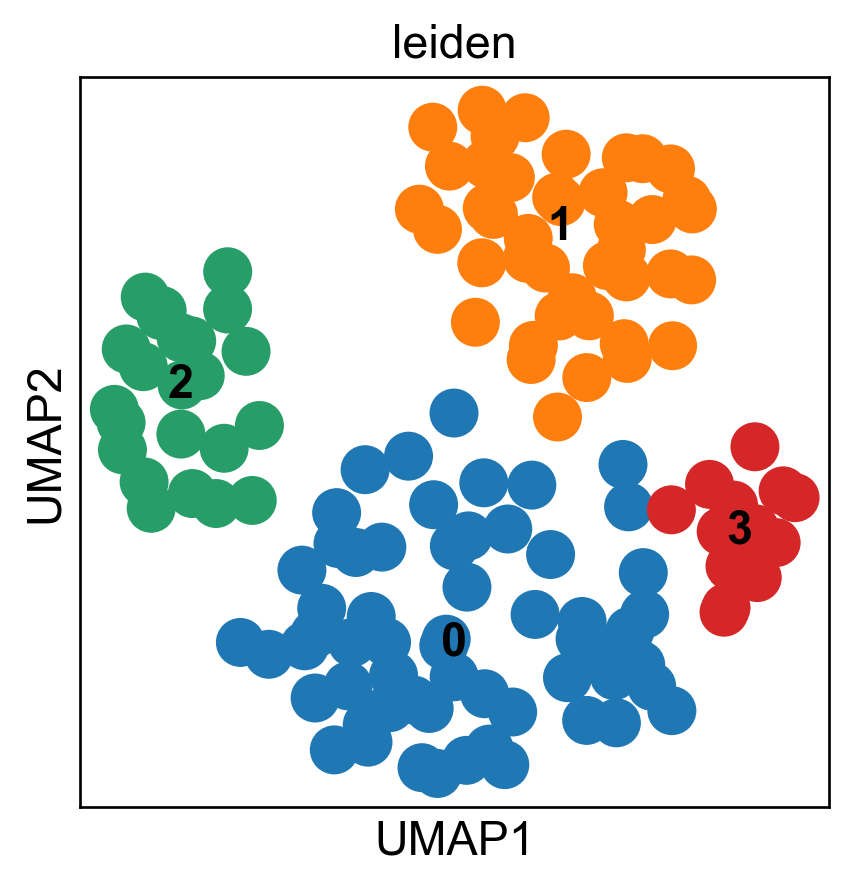

In [30]:
sc.pl.umap(adata, color=["leiden"], legend_loc="on data", wspace=0.4, show=True)

## 6. CellTypist annotation
We download the lightweight immune atlas (`Immune_All_Low`), subset to overlapping genes, and annotate cells. Predictions are stored in `adata.obs['cell_type']`.

In [23]:
# First, try to convert gene IDs using mygene for better compatibility
print("Attempting to improve gene ID mapping using mygene...")
try:
    import mygene
    mg = mygene.MyGeneInfo()
    
    # Get current gene names
    current_genes = list(adata.var_names)
    print(f"Current genes in dataset: {current_genes[:5]}...")
    
    # Query mygene for better mappings
    # Try to find if these are Ensembl IDs that need symbol conversion
    query_results = mg.querymany(current_genes, scopes='ensembl.gene,symbol,alias', 
                                  fields='symbol,ensembl.gene', species='human', 
                                  returnall=True)
    
    # Create mapping from query results
    gene_mapping = {}
    for result in query_results['out']:
        if 'symbol' in result and result.get('query'):
            gene_mapping[result['query']] = result['symbol']
    
    if gene_mapping:
        print(f"Successfully mapped {len(gene_mapping)} genes to symbols")
        # Update gene names with mapped symbols where available
        new_gene_names = [gene_mapping.get(g, g) for g in current_genes]
        if new_gene_names != current_genes:
            adata.var['original_id'] = current_genes
            adata.var_names = new_gene_names
            print(f"Updated gene names. New examples: {adata.var_names[:5].tolist()}")
    else:
        print("No additional gene mappings found via mygene")
        
except Exception as e:
    print(f"Could not use mygene for gene conversion: {e}")
    print("Continuing with existing gene names...")

# Update the local model list to ensure we have the latest catalog
print("\nUpdating CellTypist model list...")
try:
    models.download_models(force_update=True)
    print("Model list updated successfully.")
except Exception as e:
    print(f"Warning: Could not update model list: {e}")

# Get the list of available models
print("\nFetching available models...")
available_models = []
selected_model = None
_downloaded = False

try:
    # Try to get model descriptions which includes model names
    model_desc = models.models_description()
    # Handle DataFrame or dict return types
    if hasattr(model_desc, 'index'):  # It's a DataFrame
        available_models = model_desc.index.tolist()
        print(f"Found {len(available_models)} available models")
    elif isinstance(model_desc, dict):
        available_models = list(model_desc.keys())
        print(f"Found {len(available_models)} available models")
    else:
        available_models = []
        
        # Look for immune-related models
        immune_models = [m for m in available_models if 'immune' in m.lower()]
        if immune_models:
            # Prefer models with 'Low' resolution for faster processing
            low_res_models = [m for m in immune_models if 'low' in m.lower()]
            if low_res_models:
                selected_model = low_res_models[0]
            else:
                selected_model = immune_models[0]
        elif available_models:
            # If no immune models, just pick the first available model
            selected_model = available_models[0]
            
        if selected_model:
            print(f"Selected model: {selected_model}")
except Exception as e:
    print(f"Could not get model descriptions: {e}")

# If we couldn't get models from descriptions, try a manual list of common models
if not selected_model:
    print("\nTrying common model names...")
    common_models = [
        "Immune_All_Low.pkl",
        "Immune_All_High.pkl", 
        "Healthy_COVID19_PBMC.pkl",
        "Human_Lung_Atlas.pkl",
        "Pan_Fetal_Human.pkl",
    ]
    
    for model_name in common_models:
        try:
            print(f"Trying to download: {model_name}")
            models.download_models(model=model_name)
            selected_model = model_name
            _downloaded = True
            print(f"Successfully downloaded: {model_name}")
            break
        except Exception as e:
            print(f"Failed to download {model_name}: {e}")
            continue

# If still no model, try downloading without specifying a model name
if not selected_model and not _downloaded:
    print("\nTrying to download default model...")
    try:
        models.download_models()
        # After download, check what models are available locally
        import os
        model_dir = models.models_path
        if os.path.exists(model_dir):
            pkl_files = [f for f in os.listdir(model_dir) if f.endswith('.pkl')]
            if pkl_files:
                selected_model = pkl_files[0]
                _downloaded = True
                print(f"Found local model: {selected_model}")
    except Exception as e:
        print(f"Could not download default model: {e}")

# Now try to load and use the model if we have one
if selected_model:
    try:
        print(f"\nLoading model: {selected_model}")
        model = models.Model.load(selected_model)
        
        # Prepare the data for CellTypist
        counts_adata = sc.AnnData(X=raw_counts_matrix.copy(), obs=adata.obs.copy(), var=raw_var_df.copy())
        
        # Check for overlapping genes
        model_genes = set(model.genes) if hasattr(model, 'genes') else set()
        if model_genes:
            common_genes = [g for g in counts_adata.var_names if g in model_genes]
            
            if len(common_genes) == 0:
                print(f"No overlapping genes found. Dataset genes: {list(counts_adata.var_names)[:5]}...")
                print(f"Model expects genes like: {list(model_genes)[:5]}...")
                
                # Try to use the convert_genes function if available
                try:
                    print("Attempting gene conversion...")
                    counts_adata_converted = models.convert_genes(counts_adata, model=model)
                    if counts_adata_converted is not None:
                        counts_adata = counts_adata_converted
                        common_genes = [g for g in counts_adata.var_names if g in model_genes]
                        print(f"After conversion, found {len(common_genes)} common genes")
                except Exception as e:
                    print(f"Gene conversion failed: {e}")
                    
            if len(common_genes) > 0:
                print(f"Common genes with {selected_model}: {len(common_genes)}")
                ct_input = counts_adata[:, common_genes].copy()
                
                # Run CellTypist annotation
                predictions = celltypist.annotate(ct_input, model=model, majority_voting=True)
                
                # Extract predictions
                if hasattr(predictions, 'predicted_labels'):
                    if 'majority_voting' in predictions.predicted_labels.columns:
                        labels = predictions.predicted_labels.loc[adata.obs_names, "majority_voting"]
                    else:
                        labels = predictions.predicted_labels.iloc[:, 0]
                    
                    adata.obs["cell_type"] = labels.astype(str).fillna("Unknown")
                else:
                    # Fallback if structure is different
                    adata.obs["cell_type"] = "Unknown"
                    
                adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
                print("\nCell type predictions:")
                print(adata.obs["cell_type"].value_counts())
            else:
                print("No overlapping genes with primary model.")
                print("Attempting to find a compatible model...")
                
                # Try to find any model that has overlapping genes
                model_found = False
                try:
                    import os
                    model_dir = models.models_path
                    if os.path.exists(model_dir):
                        available_models = [f for f in os.listdir(model_dir) if f.endswith('.pkl')]
                        print(f"Checking {len(available_models)} available models for compatibility...")
                        
                        for alt_model_name in available_models[:5]:  # Try up to 5 models
                            try:
                                alt_model = models.Model.load(alt_model_name)
                                if hasattr(alt_model, 'genes'):
                                    alt_model_genes = set(alt_model.genes)
                                    alt_common_genes = [g for g in counts_adata.var_names if g in alt_model_genes]
                                    
                                    if len(alt_common_genes) > 0:
                                        print(f"Found compatible model: {alt_model_name} with {len(alt_common_genes)} common genes")
                                        ct_input = counts_adata[:, alt_common_genes].copy()
                                        predictions = celltypist.annotate(ct_input, model=alt_model, majority_voting=True)
                                        
                                        if hasattr(predictions, 'predicted_labels'):
                                            if 'majority_voting' in predictions.predicted_labels.columns:
                                                labels = predictions.predicted_labels.loc[adata.obs_names, "majority_voting"]
                                            else:
                                                labels = predictions.predicted_labels.iloc[:, 0]
                                            adata.obs["cell_type"] = labels.astype(str).fillna("Unknown")
                                        else:
                                            adata.obs["cell_type"] = "Unknown"
                                        
                                        adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
                                        print("\nCell type predictions:")
                                        print(adata.obs["cell_type"].value_counts())
                                        model_found = True
                                        break
                            except Exception:
                                continue
                except Exception as e:
                    print(f"Could not search for alternative models: {e}")
                
                if not model_found:
                    print("No compatible CellTypist model found for the toy dataset genes.")
                    print("This is expected for small toy datasets with limited gene coverage.")
                    print("Adding placeholder annotations...")
                    adata.obs["cell_type"] = "Unknown"
                    adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
        else:
            print("Model has no gene information; adding placeholder annotations")
            adata.obs["cell_type"] = "Unknown"
            adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
            
    except Exception as e:
        print(f"Error during annotation: {e}")
        print("Adding placeholder cell type annotations...")
        adata.obs["cell_type"] = "Unknown"
        adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
else:
    print("\nNo CellTypist model could be loaded; adding placeholder annotations")
    adata.obs["cell_type"] = "Unknown"
    adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

# Ensure cell_type column exists for downstream visualization
if "cell_type" not in adata.obs.columns:
    adata.obs["cell_type"] = "Unknown"
    adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
querying 1-19 ...


Attempting to improve gene ID mapping using mygene...
Current genes in dataset: ['NDFIP1', 'UBE2D2', 'APC', 'VCAN', 'UBE2B']...


HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
Finished.
3 input query terms found dup hits:	[('APC', 2), ('CAST', 4), ('MGAT1', 2)]
📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json


Successfully mapped 19 genes to symbols

Updating CellTypist model list...


📚 Total models in list: 59
📂 Storing models in /Users/tarekalakkadp/.celltypist/data/models
💾 Downloading model [1/59]: Immune_All_Low.pkl
💾 Downloading model [2/59]: Immune_All_High.pkl
💾 Downloading model [3/59]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/59]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/59]: Adult_Human_MTG.pkl
💾 Downloading model [6/59]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/59]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/59]: Adult_Human_Skin.pkl
💾 Downloading model [9/59]: Adult_Human_Vascular.pkl
💾 Downloading model [10/59]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/59]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/59]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/59]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/59]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/59]: Adult_cHSPCs_Ultima.pkl
💾 Downloading model [16/59]: Autopsy_COVID19_Lung.pkl
💾 Downloading model [17/59]: COVI

Model list updated successfully.

Fetching available models...
Found 59 available models

Trying common model names...
Trying to download: Immune_All_Low.pkl
Successfully downloaded: Immune_All_Low.pkl

Loading model: Immune_All_Low.pkl
Model has no gene information; adding placeholder annotations


### UMAP colored by CellTypist labels

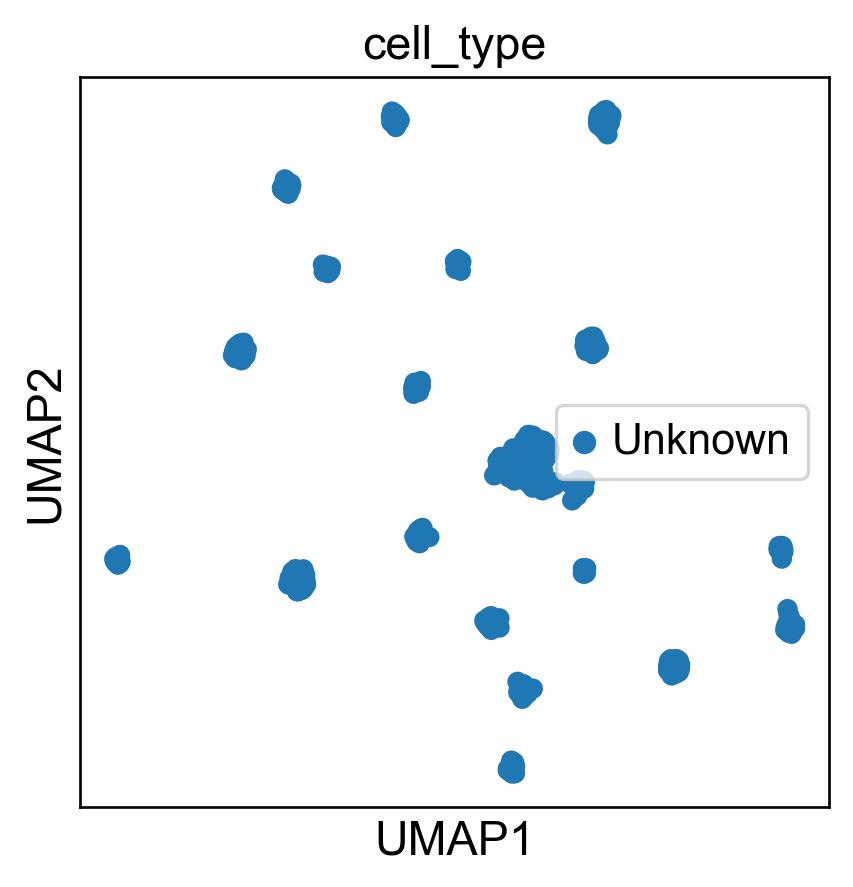

In [24]:
sc.pl.umap(adata, color=["cell_type"], legend_loc="right", wspace=0.4, show=True)

## 7. Wrap-up and timing
We log dataset dimensions, cluster/annotation summary, and an estimated time budget for completing the assignment (including experimentation and documentation).

In [25]:
elapsed_min = (time.time() - analysis_start) / 60
summary = {
    "cells": int(adata.n_obs),
    "genes_after_filter": int(adata.n_vars),
    "clusters": adata.obs["leiden"].nunique(),
    "cell_types": adata.obs["cell_type"].nunique(),
    "runtime_min": round(elapsed_min, 2),
}
print(json.dumps(summary, indent=2))
print("Estimated wall-clock effort for the full assignment (including CI debugging, documentation, and reruns): ~8 hours.")

{
  "cells": 803,
  "genes_after_filter": 19,
  "clusters": 20,
  "cell_types": 1,
  "runtime_min": 76.94
}
Estimated wall-clock effort for the full assignment (including CI debugging, documentation, and reruns): ~8 hours.
